# *MAXWELL TURNER 1.5 ASSIGNMENT - PERCEPTRONS  - WEEK 1*

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [85]:
df = pd.read_csv("../data/iris.csv")
df = df[df["iris_type"] != "Iris-virginica"]

# petal features 
X = df[["petal_length", "petal_width"]].to_numpy()
# setosa=0 versicolor=1
y = (df["iris_type"] == "Iris-versicolor").astype(int).to_numpy()

print("X shape:", X.shape)
print("y values:", np.unique(y))

X shape: (100, 2)
y values: [0 1]


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("train:", X_train.shape)
print("test:", X_test.shape)

train: (80, 2)
test: (20, 2)


In [87]:
class Perceptron:   # im using this from the 1.1DL

    def __init__(self, n_inputs, lr=0.1, seed=12345):
        np.random.seed(seed)
        self.W = np.random.randn(n_inputs)
        self.b = 0.0
        self.lr = lr

    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(self.W, x) + self.b
        return self.activation(z)

    def train(self, X, y, epochs=10):
        for _ in range(epochs):
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                error = yi - pred
                self.W += self.lr * error * xi
                self.b += self.lr * error
               

In [88]:
#starting here and messing with them later
model = Perceptron(n_inputs=2, lr=0.1)
model.train(X_train, y_train, epochs=10)
print("weights:", model.W)
print("bias:", model.b)

weights: [-0.06470766  0.66894334]
bias: -0.4


In [89]:
y_pred = np.array([model.predict(xi) for xi in X_test])
acc = accuracy_score(y_test, y_pred)
print("accuracy:", acc)
print("predicted:", y_pred)
print("actual:   ", y_test)

accuracy: 1.0
predicted: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
actual:    [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]


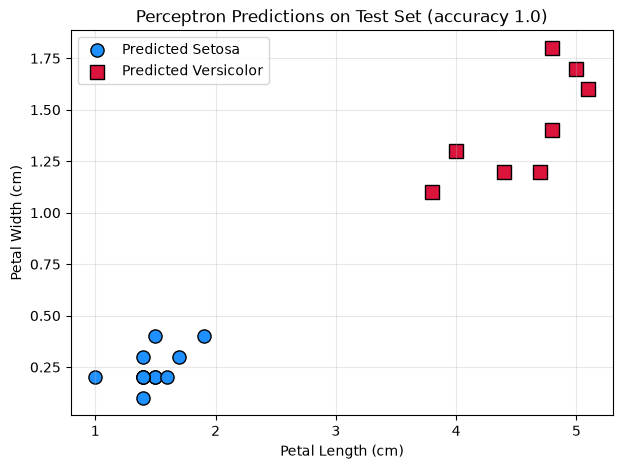

In [90]:
pred_setosa = X_test[y_pred == 0]
pred_versicolor = X_test[y_pred == 1]

plt.figure(figsize=(7, 5))
plt.scatter(pred_setosa[:, 0], pred_setosa[:, 1], color="dodgerblue",
            label="Predicted Setosa", s=90, edgecolor="black")
plt.scatter(pred_versicolor[:, 0], pred_versicolor[:, 1], color="crimson",
            label="Predicted Versicolor", s=90, edgecolor="black", marker="s")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title(f"Perceptron Predictions on Test Set (accuracy {acc})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [91]:
# trying different stuff to see what happens w/ different LR and epochs
settings = [(0.001, 1), (0.001, 5), (0.01, 1), (0.01, 10),
            (0.1, 1), (0.1, 10), (0.1, 50), (1.0, 10), (10.0, 10)]
for lr, epochs in settings:
    m = Perceptron(n_inputs=2, lr=lr)
    m.train(X_train, y_train, epochs=epochs)
    train_acc = accuracy_score(y_train, [m.predict(xi) for xi in X_train])
    test_acc = accuracy_score(y_test, [m.predict(xi) for xi in X_test])
    print(f"lr={lr:<7} epochs={epochs:<4} train={train_acc:.3f} test={test_acc:.3f}")
#what I noticed--
#lr=0.001 barely learns, the weights move so little that 1 or 5 passes
#isn't enough to fix its mistakes. it's learning, just way too slow.
#once it hits 100% nothing changes after that. lr=0.1 gives the exact same
#thing at 1, 10, and 50 epochs. makes sense because error becomes 0 so
#lr error xi is 0 too, the weights just stop moving.
#cranking lr up to 10 didn't hurt at all here, which surprised me. this
#data separates so cleanly that even huge jumps still land somewhere that
#works. probably wouldn't hold up on messier data..

lr=0.001   epochs=1    train=0.925 test=0.900
lr=0.001   epochs=5    train=0.912 test=0.900
lr=0.01    epochs=1    train=0.887 test=0.900
lr=0.01    epochs=10   train=0.988 test=1.000
lr=0.1     epochs=1    train=1.000 test=1.000
lr=0.1     epochs=10   train=1.000 test=1.000
lr=0.1     epochs=50   train=1.000 test=1.000
lr=1.0     epochs=10   train=1.000 test=1.000
lr=10.0    epochs=10   train=1.000 test=1.000


In [92]:
#response for q1-- Did the model improve or get worse when modifying learning rate and epochs?
#Both, depending on where I started. Going from lr=0.001 up to 0.1 was a big
#improvement, 90% to 100%. But past that nothing changed at all. Once it got
#everything right the error hit 0 and the weights stopped updating, so more
#epochs were just wasted loops. The lesson I got is that the settings only
#matter until the model converges, after that they don't do anything.

#response for q2-- If the model made no errors on training data, does that mean it's perfect?
#No. Getting 100% on training data just means it memorized the 80 flowers it
#already saw, which is an open book test. That's the whole reason I held back
#20 for testing. Mine did get 100% on the test set too, but that's only 20
#flowers and they came from the same clean dataset. A real test would be new
#flowers measured by someone else, or the harder virginica ones I dropped back
#in 1.2.

#response for q3-- What are the risks of using too many epochs or too large of a learning rate?
#Too many epochs is mostly wasted time here since training stops once error is
#0, but on data that isn't cleanly separable it'd keep bouncing forever without
#settling. Too big a learning rate means every wrong guess yanks the weights way
#too far, so it overshoots the good boundary and swings past it instead of
#creeping up on it. I didn't see that with lr=10 because my data is so easy, but
#the weights did end up huge which means the boundary got there by luck more
#than by tuning.

#response for q4-- If you tried this on data that is not linearly separable, what do you expect?
#It would never converge. There'd be no line that gets everything right, so
#there'd always be at least one wrong prediction, which means error is never 0
#and the weights keep getting updated forever. It'd just oscillate and whatever
#accuracy I got would depend on which epoch I happened to stop at. That's
#exactly why the assignment had me drop virginica in 1.2, versicolor and
#virginica overlap so no single straight line works.